In [ ]:
!pip install pyspark

from pyspark.sql import SparkSession
from pyspark.sql.functions import explode, split, col

spark = SparkSession.builder \
    .appName("PySpark_MapReduce") \
    .getOrCreate()

data = [
    ("hola mundo hola"),
    ("hola pyspark pyspark pyspark"),
    ("big data con pyspark"),
    ("map reduce con pyspark"),
    ("big data hadoop spark")
]

rdd = spark.sparkContext.parallelize(data)
df = rdd.map(lambda x: (x, )).toDF(["sentence"])

# Map
df_words = df.select(explode(split(col("sentence"), " ")).alias("word"))
# Reduce
word_counts = df_words.groupBy("word").count()

word_counts.show()

+-------+-----+
|   word|count|
+-------+-----+
|pyspark|    5|
|   hola|    3|
|  mundo|    1|
|    map|    1|
|    con|    2|
|   data|    2|
| reduce|    1|
|  spark|    1|
| hadoop|    1|
|    big|    2|
+-------+-----+



In [ ]:
!pip install pyspark

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, split, explode, sha2, concat_ws, avg, sum, count, min, max
import random

spark = SparkSession.builder.appName("PySpark_Demo").getOrCreate()

print("\n 1. MAP REDUCE - Conteo de Palabras")
data = [("Hola mundo"), ("Hola Spark"), ("PySpark es potente"), ("Hola mundo PySpark")]
df = spark.createDataFrame([(d,) for d in data], ["sentence"])
words = df.select(explode(split(col("sentence"), " ")).alias("word"))
word_counts = words.groupBy("word").count()
word_counts.show()

print("\n 2. SUMA DE VERIFICACIÓN")
data = [("Hola mundo"), ("Hola Spark"), ("PySpark es potente")]
df = spark.createDataFrame([(d,) for d in data], ["sentence"])
checksum_df = df.withColumn("checksum", sha2(col("sentence"), 256))
checksum_df.show(truncate=False)

print("\n 3. FILTRADO Y AGRUPACIÓN")
data = [("Ana", 25), ("Carlos", 30), ("Andrés", 22), ("Beatriz", 29)]
df = spark.createDataFrame(data, ["nombre", "edad"])
df_filtered = df.filter(col("nombre").startswith("A"))
df_filtered.show()

print("\n 4. ORDENACIÓN DISTRIBUIDA")
data = [(random.randint(1, 100),) for _ in range(10)]
df = spark.createDataFrame(data, ["numero"])
df_sorted = df.orderBy("numero")
df_sorted.show()

print(" 5. CÁLCULO DE MEDIA Y SUMA")
data = [(random.randint(1, 100),) for _ in range(10)]
df = spark.createDataFrame(data, ["valor"])
df_stats = df.select(avg("valor").alias("media"), sum("valor").alias("suma"))
df_stats.show()

print("\ 6. AGRUPACIÓN Y ESTADÍSTICAS")
data = [("A", random.randint(1, 100)) for _ in range(5)] + [("B", random.randint(1, 100)) for _ in range(5)]
df = spark.createDataFrame(data, ["grupo", "valor"])
df_grouped = df.groupBy("grupo").agg(
    count("valor").alias("conteo"),
    min("valor").alias("min"),
    max("valor").alias("max"),
    avg("valor").alias("media")
)
df_grouped.show()



 1. MAP REDUCE - Conteo de Palabras
+-------+-----+
|   word|count|
+-------+-----+
|   Hola|    3|
|  Spark|    1|
|  mundo|    2|
|     es|    1|
|potente|    1|
|PySpark|    2|
+-------+-----+


 2. SUMA DE VERIFICACIÓN
+------------------+----------------------------------------------------------------+
|sentence          |checksum                                                        |
+------------------+----------------------------------------------------------------+
|Hola mundo        |ca8f60b2cc7f05837d98b208b57fb6481553fc5f1219d59618fd025002a66f5c|
|Hola Spark        |9ef85f21187c6a608c8154b559e86525e880b1d4d3b7d0815cd9a647b6b7e438|
|PySpark es potente|e26a1ff6ff1d0dcab16ff4f9c888b0fddff4372dc4c8f689402e5eef5997d49e|
+------------------+----------------------------------------------------------------+


 3. FILTRADO Y AGRUPACIÓN
+------+----+
|nombre|edad|
+------+----+
|   Ana|  25|
|Andrés|  22|
+------+----+


 4. ORDENACIÓN DISTRIBUIDA
+------+
|numero|
+------+
|    1

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("MapReduceExample").getOrCreate()

rdd = spark.sparkContext.parallelize([
    "hola mundo", "hola Spark", "Spark es poderoso", "mundo de datos", "hola mundo"
])

rdd_map = rdd.flatMap(lambda line: line.split(" ")).map(lambda word: (word, 1))

print(rdd_map.collect())

rdd_reduce = rdd_map.reduceByKey(lambda a, b: a + b)

print(rdd_reduce.collect())


[('hola', 1), ('mundo', 1), ('hola', 1), ('Spark', 1), ('Spark', 1), ('es', 1), ('poderoso', 1), ('mundo', 1), ('de', 1), ('datos', 1), ('hola', 1), ('mundo', 1)]
[('mundo', 3), ('es', 1), ('poderoso', 1), ('hola', 3), ('Spark', 2), ('de', 1), ('datos', 1)]


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import Row

spark = SparkSession.builder \
    .appName("Ejemplo PySpark SQL en Colab") \
    .getOrCreate()

datos = [
    Row(nombre="Alice", edad=29, ciudad="Madrid"),
    Row(nombre="Bob", edad=34, ciudad="Barcelona"),
    Row(nombre="Cathy", edad=29, ciudad="Madrid"),
    Row(nombre="David", edad=34, ciudad="Valencia"),
    Row(nombre="Eve", edad=29, ciudad="Madrid"),
]

df = spark.createDataFrame(datos)

df.createOrReplaceTempView("personas")

consulta_1 = spark.sql("SELECT * FROM personas WHERE ciudad = 'Madrid'")
print("Consulta 1: Personas en Madrid")
consulta_1.show()

consulta_2 = spark.sql("SELECT ciudad, COUNT(*) AS total_personas FROM personas GROUP BY ciudad")
print("Consulta 2: Conteo por ciudad")
consulta_2.show()

consulta_3 = spark.sql("SELECT AVG(edad) AS edad_promedio FROM personas")
print("Consulta 3: Edad promedio")
consulta_3.show()

consulta_4 = spark.sql("SELECT ciudad, COUNT(*) AS total FROM personas GROUP BY ciudad HAVING total > 1")
print("Consulta 4: Ciudades con más de una persona")
consulta_4.show()


Consulta 1: Personas en Madrid
+------+----+------+
|nombre|edad|ciudad|
+------+----+------+
| Alice|  29|Madrid|
| Cathy|  29|Madrid|
|   Eve|  29|Madrid|
+------+----+------+

Consulta 2: Conteo por ciudad
+---------+--------------+
|   ciudad|total_personas|
+---------+--------------+
|   Madrid|             3|
|Barcelona|             1|
| Valencia|             1|
+---------+--------------+

Consulta 3: Edad promedio
+-------------+
|edad_promedio|
+-------------+
|         31.0|
+-------------+

Consulta 4: Ciudades con más de una persona
+------+-----+
|ciudad|total|
+------+-----+
|Madrid|    3|
+------+-----+



In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType

spark = SparkSession.builder.appName("SQL_Advanced_Examples").getOrCreate()

schema = StructType([
    StructField("name", StringType(), True),
    StructField("age", IntegerType(), True),
    StructField("city", StringType(), True),
    StructField("score", IntegerType(), True)
])

data = [
    ("Alice", 30, "New York", 85),
    ("Bob", 25, "Los Angeles", 75),
    ("Charlie", 35, "New York", 95),
    ("David", 40, "Chicago", 65),
    ("Eve", 29, "New York", 70),
    ("Frank", 30, "Chicago", 80),
    ("Grace", 22, "Los Angeles", 85)
]
df = spark.createDataFrame(data, schema=schema)

df.createOrReplaceTempView("people")


SELECT
    city,
    CASE
        WHEN age < 30 THEN 'Young'
        WHEN age >= 30 AND age < 40 THEN 'Mid-age'
        ELSE 'Older'
    END AS age_group,
    AVG(score) AS avg_score
FROM people
GROUP BY city, age_group


In [ ]:
result1 = spark.sql("""
SELECT
    city,
    CASE
        WHEN age < 30 THEN 'Young'
        WHEN age >= 30 AND age < 40 THEN 'Mid-age'
        ELSE 'Older'
    END AS age_group,
    AVG(score) AS avg_score
FROM people
GROUP BY city, age_group
""")
result1.show()


+-----------+---------+---------+
|       city|age_group|avg_score|
+-----------+---------+---------+
|   New York|  Mid-age|     90.0|
|Los Angeles|    Young|     80.0|
|   New York|    Young|     70.0|
|    Chicago|  Mid-age|     80.0|
|    Chicago|    Older|     65.0|
+-----------+---------+---------+



DataFrame[city: string, count: bigint]
          city  count
0  Los Angeles      2
1     New York      3
2      Chicago      2


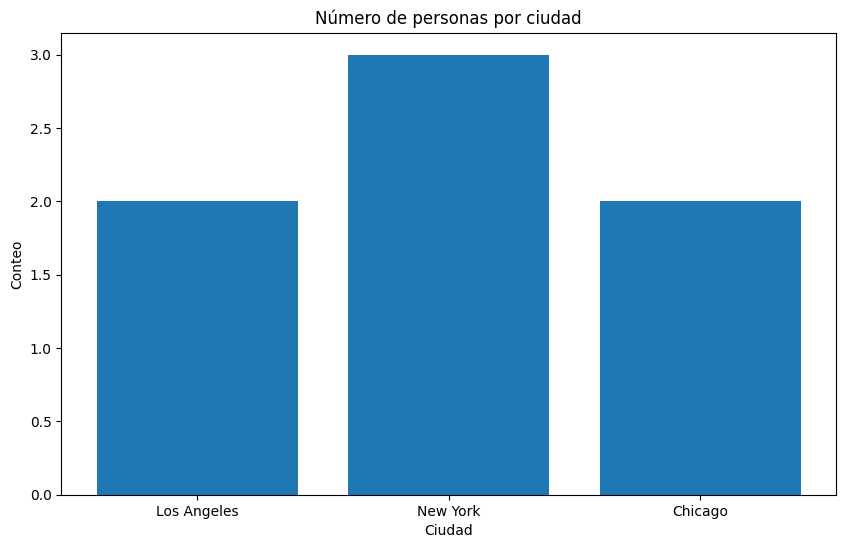

In [ ]:
import matplotlib.pyplot as plt

from pyspark.sql import functions as F
city_counts = df.groupBy("city").count()
print(city_counts)
city_counts_pd = city_counts.toPandas()
print(city_counts_pd)

plt.figure(figsize=(10, 6))
plt.bar(city_counts_pd['city'], city_counts_pd['count'])
plt.xlabel("Ciudad")
plt.ylabel("Conteo")
plt.title("Número de personas por ciudad")
plt.show()
